wandbからダウンロードしたsuccess/timeのcsvを読み込んで、グラフを描画するスクリプト。
x軸をglobal stepにしてダウンロードすることを忘れずに。

In [21]:
# Success/timeのデータ使う
sapg = {
        "csv": "/Users/naokishitanda/my_local_gitcode/sapg2/data/exp_0117/0117-1/src/SAPG-24576.csv",
        "label": "sapg",
    }

test = {
        "csv": "/Users/naokishitanda/my_local_gitcode/sapg2/data/exp_0117/0117-1/src/wandb_export_2025-01-22T18_44_31.035+09_00.csv",
        "label": "test",
    }


In [22]:
# sapgのデータを可視化する(stap数ごとのデータがrunごとにmean, min. maxの順で並んでいる。つまり合計24列。ただし抜けている箇所もある)
# meanだけを取り出して、平均と標準偏差をプロットする
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 複数シードのデータ用
def plot_success_step_multiseed(data_dict, num_data, plot_mean_dev=False, lw=1, alpha=0.3):
    assert num_data > 1, "num_data must be greater than 1"
    # meanを抽出するための列番号を取得
    indices = [i for i in range(4, num_data*6, 6)]
    # csvファイルを読み込む
    df = pd.read_csv(data_dict["csv"])
    # データとステップ数を取り出す
    steps = df.iloc[:,[0]].values.tolist()
    steps = np.array(steps).reshape(-1)
    data = df.iloc[:,indices]
    data_array = data.values.tolist()
    data_array = np.array(data_array).T
    # 列ごとに[[steps], [mean]]にしてリストに格納
    data_array = [[steps, data] for data in data_array]
    data_array = np.array(data_array)    
        
    if not plot_mean_dev:
        for i in range(data_array.shape[0]):
            plt.plot(data_array[i][0], data_array[i][1], label=f"{data_dict["label"]}_run{i}", lw=lw)
    else:
        # np.arrayのnan部分を線形補完
        for i in range(data_array.shape[0]):
            nan_idx = np.isnan(data_array[i][1])
            x = np.arange(len(data_array[i][1]))
            data_array[i][1][nan_idx] = np.interp(x[nan_idx], x[~nan_idx], data_array[i][1][~nan_idx])
            
        # 平均と標準偏差を計算
        mean = np.mean(data_array[:,1], axis=0)
        std = np.std(data_array[:,1], axis=0)
        # プロット
        plt.plot(steps, mean, label=data_dict["label"], lw=lw)
        plt.fill_between(steps, mean-std, mean+std, alpha=alpha)
        
# 単一シードのデータ用 
def plot_success_step_singleseed(data_dict, lw=1):
    # meanを抽出するための列番号を取得
    indices = [4]
    # csvファイルを読み込む
    df = pd.read_csv(data_dict["csv"])
    # データとステップ数を取り出す
    steps = df.iloc[:,[0]].values.tolist()
    steps = np.array(steps).reshape(-1)
    data = df.iloc[:,indices]
    data_array = data.values.tolist()
    data_array = np.array(data_array).T
    # 列ごとに[[steps], [mean]]にしてリストに格納
    data_array = [[steps, data] for data in data_array]
    data_array = np.array(data_array)    
        
    plt.plot(data_array[0][0], data_array[0][1], label=f"{data_dict["label"]}", lw=lw) 


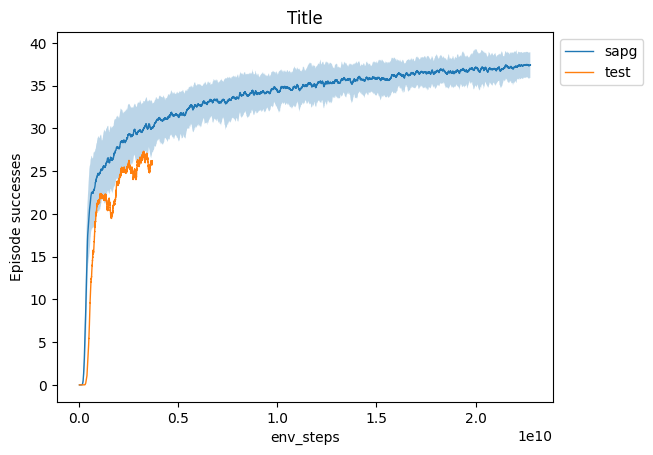

In [28]:
# SAPGのデータをプロット
plot_success_step_multiseed(sapg, num_data=8, plot_mean_dev=True, lw=1, alpha=0.3)
# testのデータをプロット
plot_success_step_singleseed(test, lw=1)

# 表示
plt.xlabel("env_steps")
plt.ylabel("Episode successes") # Success/timeのデータ使う
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.title("Title")
plt.show()
